In [77]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load dataset
df = pd.read_csv("/content/Website_Data.csv")
pd.set_option('display.max_columns', None)

In [80]:
# Preview data
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.52666667,0.607594937,4.673333333,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737828,0.634615385,4.29588015,0.494382022,1147
3,Direct,2024041723,188,233,115,39.93991416,0.611702128,4.587982833,0.493562232,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.668449198,4.078125,0.48828125,1044


In [81]:
# Rename columns for better readability
df.columns= [
"channel_group",
"datetime",
"users",
"sessions",
"engaged_sessions",
"avg_engagement_time_per_session",
"engaged_sessions_per_user",
"events_per_session",
"engagement_rate",
"event_count"
]
df= df.iloc[1:].reset_index(drop=True)


In [82]:
df.head()

,channel_group,datetime,users,sessions,engaged_sessions,avg_engagement_time_per_session,engaged_sessions_per_user,events_per_session,engagement_rate,event_count
0,Direct,2024041623,237,300,144,47.52666667,0.607594937,4.673333333,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737828,0.634615385,4.29588015,0.494382022,1147
2,Direct,2024041723,188,233,115,39.93991416,0.611702128,4.587982833,0.493562232,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.668449198,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.91855204,0.64,4.529411765,0.50678733,1001


In [83]:
# Check data types
df.dtypes

,0
channel_group,object
datetime,object
users,object
sessions,object
engaged_sessions,object
avg_engagement_time_per_session,object
engaged_sessions_per_user,object
events_per_session,object
engagement_rate,object
event_count,object


In [84]:
# Convert datetime column to proper format
df['datetime'] = pd.to_datetime(df['datetime'], format='%Y%m%d%H', errors='coerce')

In [85]:
# Convert all numeric columns to numeric type
numeric_cols = df.columns.drop(['channel_group', 'datetime'])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Extract hour from datetime for time-based analysis
df['hour'] = df['datetime'].dt.hour

In [86]:
df.head()

,channel_group,datetime,users,sessions,engaged_sessions,avg_engagement_time_per_session,engaged_sessions_per_user,events_per_session,engagement_rate,event_count,hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [87]:
# Check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   channel_group                    3182 non-null   object        
 1   datetime                         3182 non-null   datetime64[ns]
 2   users                            3182 non-null   int64         
 3   sessions                         3182 non-null   int64         
 4   engaged_sessions                 3182 non-null   int64         
 5   avg_engagement_time_per_session  3182 non-null   float64       
 6   engaged_sessions_per_user        3182 non-null   float64       
 7   events_per_session               3182 non-null   float64       
 8   engagement_rate                  3182 non-null   float64       
 9   event_count                      3182 non-null   int64         
 10  hour                             3182 non-null   int32      

In [88]:
# Summary statistics
df.describe()

,datetime,users,sessions,engaged_sessions,avg_engagement_time_per_session,engaged_sessions_per_user,events_per_session,engagement_rate,event_count,hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


In [89]:
# Set plot style
sns.set(style='whitegrid')

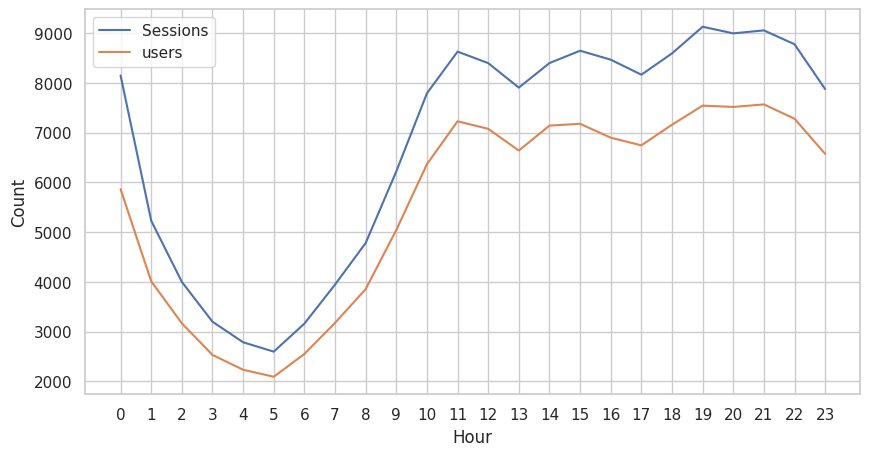

In [90]:
# Hourly trend: Sessions & Users
plt.figure(figsize=(10,5))

# Aggregate sessions and users by hour
hourly = df.groupby('hour')[['sessions', 'users']].sum().reset_index()

# Plot trends
sns.lineplot(data=hourly, x='hour', y='sessions', label='Sessions')
sns.lineplot(data=hourly, x='hour', y='users', label='users')

plt.xlabel('Hour')
plt.ylabel('Count')

plt.xticks(range(24))
plt.show()

 **Insight**: Maximum traffic occurs between 11 AM and 12 PM

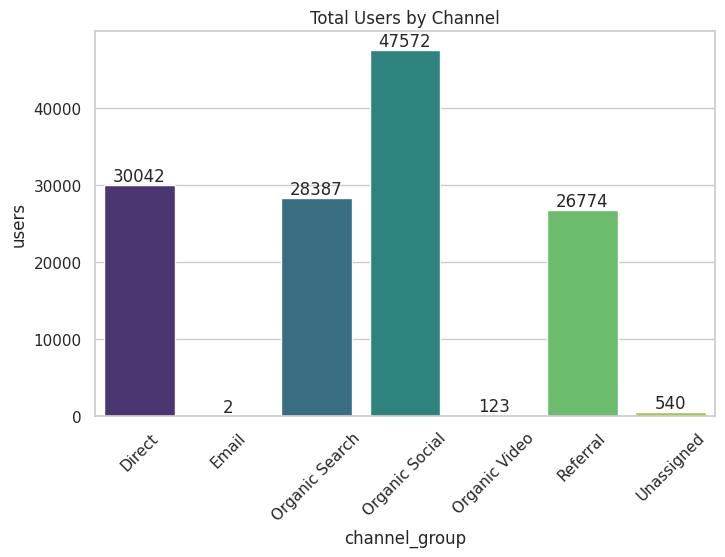

In [91]:
# Users by Channel
plt.figure(figsize=(8,5))
channel= df.groupby("channel_group")["users"].sum().reset_index()

# Bar plot
ax = sns.barplot(data=channel, x='channel_group', y='users', palette='viridis')
for container in ax.containers:
  ax.bar_label(container)

plt.title("Total Users by Channel")
plt.xticks(rotation=45)
plt.show()

**Insight**: Organic Social brings the most users, followed by Direct and Organic Search

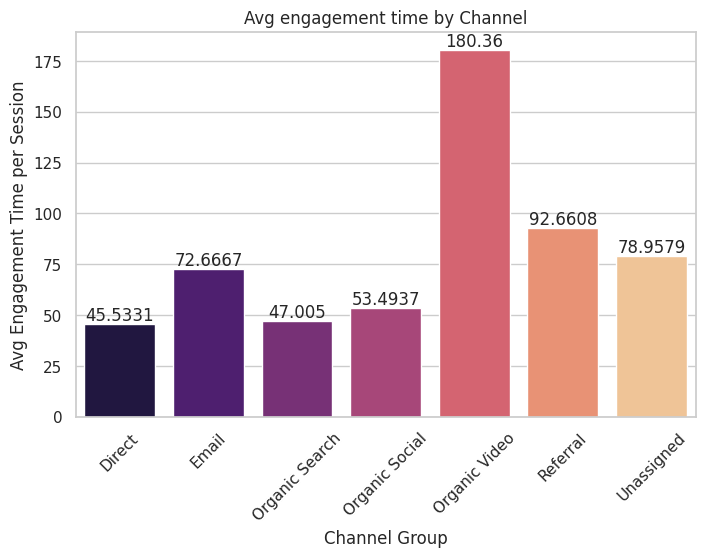

In [92]:
# Avg Engagement Time by Channel
plt.figure(figsize=(8,5))
channel= df.groupby("channel_group")["avg_engagement_time_per_session"].mean().reset_index()

ax = sns.barplot(data=channel, x='channel_group', y='avg_engagement_time_per_session', palette='magma')
for container in ax.containers:
  ax.bar_label(container)

plt.title("Avg engagement time by Channel")
plt.xlabel("Channel Group")
plt.ylabel("Avg Engagement Time per Session")
plt.xticks(rotation=45)
plt.show()

**Insight**: Although Organic Social drives the most traffic, but its average engagement time is lower than Organic Video, Email, and Referral

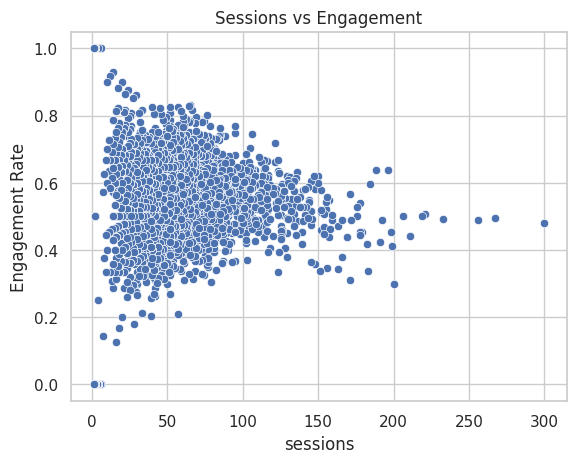

In [93]:
# Sessions vs Engagement Scatter
sns.scatterplot(x='sessions', y='engagement_rate', data=df)
plt.title("Sessions vs Engagement")
plt.ylabel("Engagement Rate")
plt.show()

In [94]:
# KPI Calculation
total_users = df['users'].sum()
total_sessions = df['sessions'].sum()
avg_engagement = df['engagement_rate'].mean().round(3)

print("Total Users:", total_users)
print("Total Sessions:", total_sessions)
print("Avg Engagement Rate:", avg_engagement)

Total Users: 133440
Total Sessions: 162895
Avg Engagement Rate: 0.503


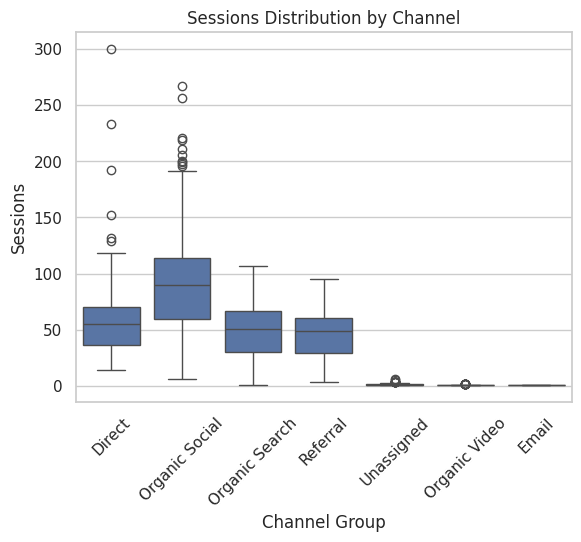

In [95]:
# Sessions Distribution by Channel
sns.boxplot(x='channel_group', y='sessions', data=df)
plt.xticks(rotation=45)
plt.xlabel("Channel Group")
plt.ylabel("Sessions")
plt.title("Sessions Distribution by Channel")
plt.show()

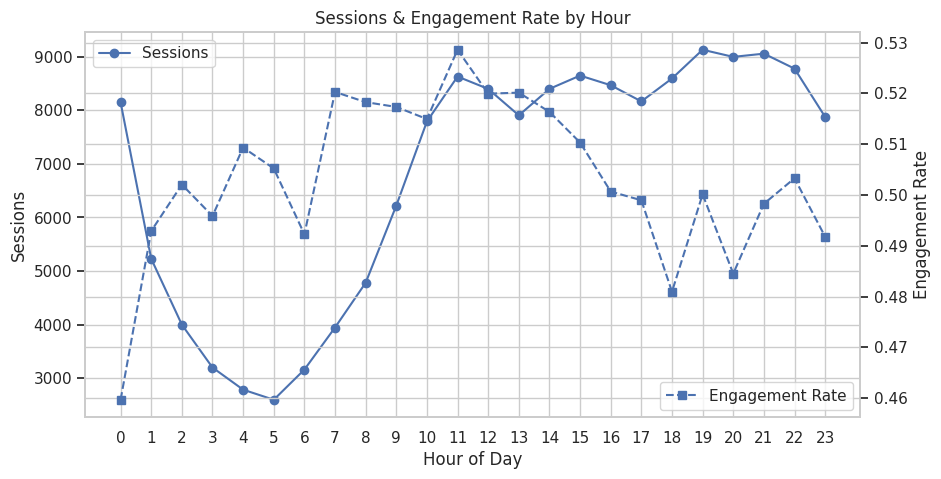

In [96]:
# Hourly Sessions vs Engagement (Dual Axis)
hourly = df.groupby('hour').agg({
    'sessions': 'sum',
    'engagement_rate': 'mean'
}).reset_index()


fig, ax1 = plt.subplots(figsize=(10,5))

# Sessions line
ax1.plot(
    hourly['hour'],
    hourly['sessions'],
    marker='o',
    linestyle='-',
    label='Sessions'
)
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Sessions")
ax1.legend(loc='upper left')   # Legend 1

# Engagement rate line
ax2 = ax1.twinx()
ax2.plot(
    hourly['hour'],
    hourly['engagement_rate'],
    marker='s',
    linestyle='--',
    label='Engagement Rate'
)
ax2.set_ylabel("Engagement Rate")
ax2.legend(loc='lower right')  # Legend 2

plt.title("Sessions & Engagement Rate by Hour")
plt.xticks(range(0,24))
plt.show()

**Insight**: User activity is low between 2 AM and 7 AM, but engagement rate is higher during this period

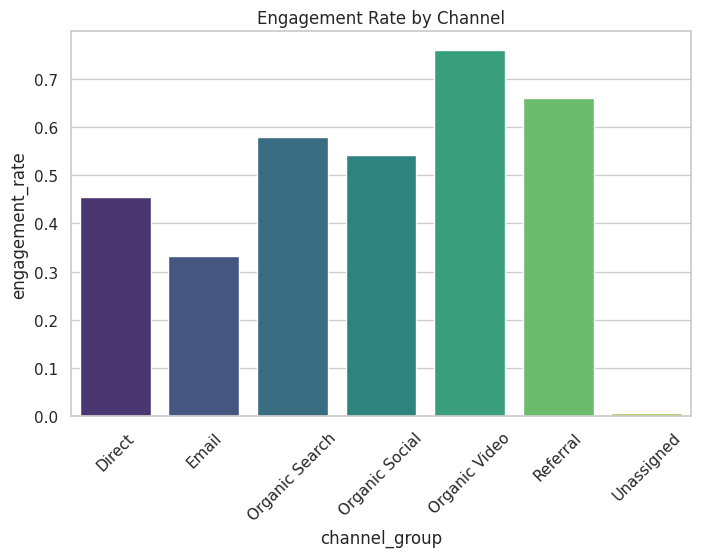

In [97]:
# Engagement Rate by Channel
channel = df.groupby('channel_group')['engagement_rate'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=channel, x='channel_group', y='engagement_rate', palette='viridis')
plt.xticks(rotation=45)
plt.title("Engagement Rate by Channel")
plt.show()

**Insight**: Organic Video has the highest engagement rate, followed by Referral and Organic Social

In [98]:
# Top Hours Analysis

# Highest traffic hours
hourly.sort_values(by='sessions', ascending=False).reset_index(drop=True).head()


,hour,sessions,engagement_rate
0,19,9129,0.500114
1,21,9056,0.498255
2,20,8996,0.484509
3,22,8777,0.503272
4,15,8647,0.510311


**Insight**: Sessions peak between 7 PM and 10 PM, likely due to post-work activity and evening time leisure browsing

In [99]:
# Highest engagement rate
hourly.sort_values(by='engagement_rate', ascending=False).reset_index(drop=True).head()

,hour,sessions,engagement_rate
0,11,8629,0.528576
1,7,3946,0.520268
2,13,7905,0.520133
3,12,8398,0.519927
4,8,4781,0.518266


Insight: Peak engagement between 11 AM and 1 PM, likely due to focused browsing during lunch or short work breaks

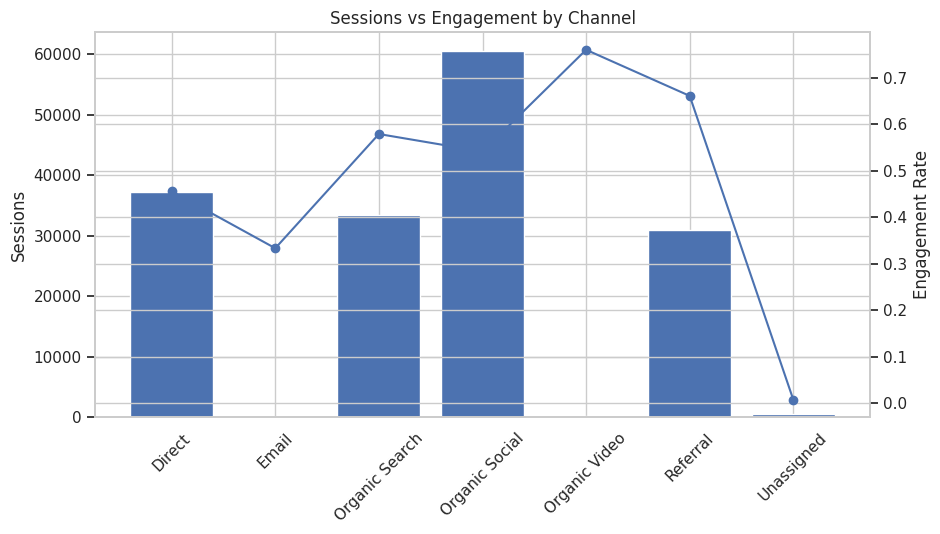

In [100]:
# Aggregate sessions and engagement rate by channel
channel_summary = df.groupby('channel_group').agg({
    'sessions': 'sum',
    'engagement_rate': 'mean'
}).reset_index()

# Create plot
fig, ax1 = plt.subplots(figsize=(10,5))

# Bar plot for sessions
ax1.bar(channel_summary['channel_group'], channel_summary['sessions'])
ax1.set_ylabel('Sessions')
ax1.set_xticklabels(channel_summary['channel_group'], rotation=45)

# Line plot for engagement rate on secondary axis
ax2 = ax1.twinx()
ax2.plot(channel_summary['channel_group'], channel_summary['engagement_rate'], marker='o')
ax2.set_ylabel('Engagement Rate')

plt.title("Sessions vs Engagement by Channel")
plt.show()

**Insight**: Email and Organic Video have low traffic but high engagement, indicating underutilized high-quality channels